This notebook clusters the counties by their characteristics without outbreak information and PHR division. The steps involves: 
1. 

In [3]:
library(dplyr)       # for data manipulation
library(ggplot2)     # for data visualization
library(stringr)     # for string functionality
library(cluster)     # for general clustering algorithms
library(factoextra)  # for visualizing cluster results
library(readr)      # for reading
# set path
library(here)
setwd(here::here())

This block is used to 

In [4]:
# read dataset and clean
df <- read_csv("data/merged_county_data.csv")
df <- df %>% filter(!County %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt"))
df_raw <- df
County <- df$County
df$density <- df$population*1.0/df$AREA_SQMI
df <- df %>% select(-c("County", "PHR", "outbreak", "AREA_SQMI"), -starts_with("M_"), -starts_with("MP_"), -starts_with("E_"), -starts_with("EPL_"), -starts_with("SPL_"), -starts_with("RPL_"), -starts_with("F_"))
df <- df[,colSums(is.na(df)) == 0]
df <- df %>% select(-c("EP_MINRTY", "EP_HISP", "EP_AFAM", "EP_POV150", "EP_UNINSUR"))
df <- as.data.frame(scale(df))  

Rows: 254 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): County
dbl (12): cve, outbreak, enrollment, population, PHR, pct_hispanic, pct_blac...
lgl  (1): median_income

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Unknown or uninitialised column: `AREA_SQMI`.”


ERROR: [1m[33mError[39m in `$<-`:[22m
[1m[22m[33m![39m Assigned data `df$population * 1/df$AREA_SQMI` must be compatible with
  existing data.
[31m✖[39m Existing data has 250 rows.
[31m✖[39m Assigned data has 0 rows.
[36mℹ[39m Only vectors of size 1 are recycled.
[1mCaused by error in `vectbl_recycle_rhs_rows()`:[22m
[33m![39m Can't recycle input of size 0 to size 250.


In [11]:
pca_out <- prcomp(df)
summary(pca_out)
names(pca_out)
pca_out$center
pca_out$rotation

Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     2.4353 2.2428 1.54094 1.26537 1.14634 1.12664 1.04668
Proportion of Variance 0.2045 0.1734 0.08188 0.05521 0.04531 0.04377 0.03778
Cumulative Proportion  0.2045 0.3780 0.45983 0.51504 0.56036 0.60413 0.64190
                           PC8     PC9    PC10    PC11    PC12    PC13    PC14
Standard deviation     1.02856 0.99222 0.96961 0.94629 0.87797 0.81385 0.77753
Proportion of Variance 0.03648 0.03395 0.03242 0.03088 0.02658 0.02284 0.02085
Cumulative Proportion  0.67839 0.71233 0.74475 0.77563 0.80221 0.82505 0.84590
                          PC15    PC16    PC17    PC18    PC19   PC20    PC21
Standard deviation     0.77072 0.76053 0.72592 0.66581 0.63980 0.6188 0.58043
Proportion of Variance 0.02048 0.01995 0.01817 0.01529 0.01412 0.0132 0.01162
Cumulative Proportion  0.86638 0.88632 0.90450 0.91978 0.93390 0.9471 0.95872
                          PC22    PC23

[1] "sdev"     "rotation" "center"   "scale"    "x"

cve       population     pct_hispanic        pct_black 
    3.588241e-16    -8.881784e-19    -5.577760e-16     3.606004e-16 
       pct_white      pct_poverty    pct_uninsured      pct_college 
   -1.492140e-16     1.154632e-15    -1.260769e-15    -1.096900e-15 
pct_foreign_born         EP_UNEMP         EP_HBURD        EP_NOHSDP 
    2.378098e-16     3.883560e-16     5.824230e-16     2.826184e-15 
        EP_AGE65         EP_AGE17        EP_DISABL        EP_SNGPNT 
    1.584510e-15    -3.271161e-15     5.170309e-16    -2.415845e-16 
       EP_LIMENG         EP_MUNIT        EP_MOBILE         EP_CROWD 
    8.260059e-17    -5.204726e-16     2.655653e-16    -1.182165e-15 
        EP_NOVEH        EP_GROUPQ         EP_NOINT         EP_ASIAN 
   -6.006758e-16    -2.859935e-16     1.103895e-15    -8.260059e-17 
         EP_AIAN          EP_NHPI       EP_TWOMORE     EP_OTHERRACE 
   -7.531753e-16     1.159073e-16     3.437250e-16    -5.648815e-16 
         density 
   -6.461498e-17

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29
cve,0.210885364,-0.011434927,0.14651546,-0.118849466,0.095864934,-0.262423714,0.084283184,0.41645926,-0.2576536849,-0.290696449,...,-0.039946502,-0.094384183,-0.251766126,0.100183368,0.112819462,0.091933899,0.106310379,-0.139400118,-0.001350531,0.062471703
population,-0.017695450,0.347676589,-0.06525533,0.230380095,0.174583015,0.020023256,0.059301481,0.16619073,-0.1458602555,-0.008585106,...,-0.117605195,0.017935386,0.031011890,-0.055603551,0.052360800,-0.205792520,0.011380545,-0.073153806,-0.635552343,0.040632186
pct_hispanic,-0.360381072,0.008798596,0.14529817,0.156326901,-0.091344228,-0.062394952,-0.115974101,-0.08712875,0.0596558428,0.071709298,...,-0.189486781,0.005122234,-0.051556628,0.299376331,0.167064769,0.033923249,-0.057993508,-0.020861429,0.054993680,0.751648488
pct_black,0.032280078,0.177716919,-0.37582491,-0.175705593,-0.031785852,0.280679223,0.134446754,0.08059639,0.0171925593,-0.117687053,...,0.260568616,-0.305400643,0.106603306,0.124607245,-0.008670177,-0.021692859,0.036524519,0.064922639,-0.038478716,0.310539817
pct_white,0.334818729,-0.139359513,0.02502204,-0.098087771,0.126469933,-0.080965942,0.039907374,0.02567173,-0.0271114087,-0.085426090,...,0.200690046,0.222772881,0.072262646,-0.413847826,-0.290121060,-0.130680201,0.013559909,0.214989971,0.049251441,0.533169273
pct_poverty,-0.265673675,-0.051830898,-0.16285457,-0.151605543,0.255823052,-0.173203803,-0.215325548,-0.05582425,-0.0386900975,-0.071631702,...,0.022190343,-0.253366849,0.199602197,-0.235044115,-0.101562848,0.138153886,0.058696346,-0.041167808,0.012690666,0.030141612
pct_uninsured,-0.269274253,-0.058125442,0.04669599,-0.005148471,0.047537950,-0.201651820,0.012865076,0.37719717,-0.1742061658,-0.169598833,...,0.189649857,0.404685354,0.228483696,0.231398333,0.087125708,0.116214358,-0.188770800,0.037539544,-0.005555670,-0.071275142
pct_college,0.195708517,0.275818487,0.12683230,0.107330953,0.075318479,-0.145954151,-0.074090807,-0.06066429,-0.0980725481,-0.045769719,...,-0.058287799,-0.090435313,0.334592066,0.285117213,-0.347156523,-0.317465376,-0.181803956,0.254041741,-0.075842512,-0.028427133
pct_foreign_born,-0.027347819,0.157068309,-0.06065114,0.133093191,-0.285200982,-0.311136832,0.351409794,-0.19192167,-0.1291792304,0.404122659,...,0.054548154,0.006752469,0.059564804,-0.213294790,0.056034420,-0.036259195,-0.070777411,0.056310783,0.005428643,-0.033494012
EP_UNEMP,-0.100010944,0.011944513,-0.35834522,-0.149195693,0.219274767,-0.065728787,0.177679195,0.24156930,0.1981483578,0.032574871,...,0.107822683,0.086271894,-0.011005028,-0.096984881,-0.050908259,0.006124566,-0.060731338,-0.039797141,-0.001238616,0.003208057


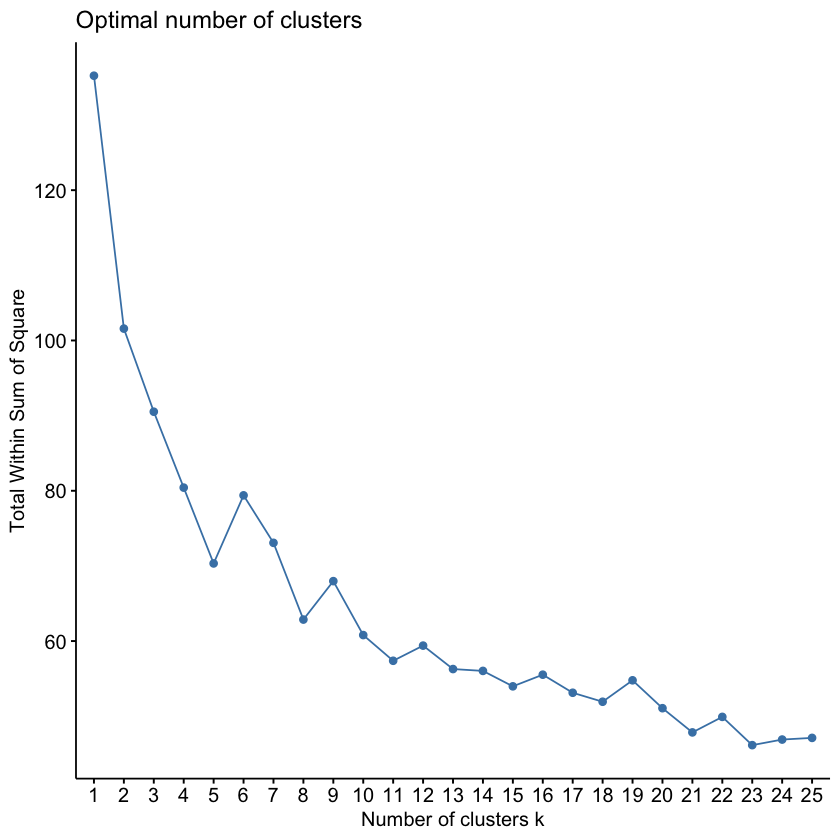

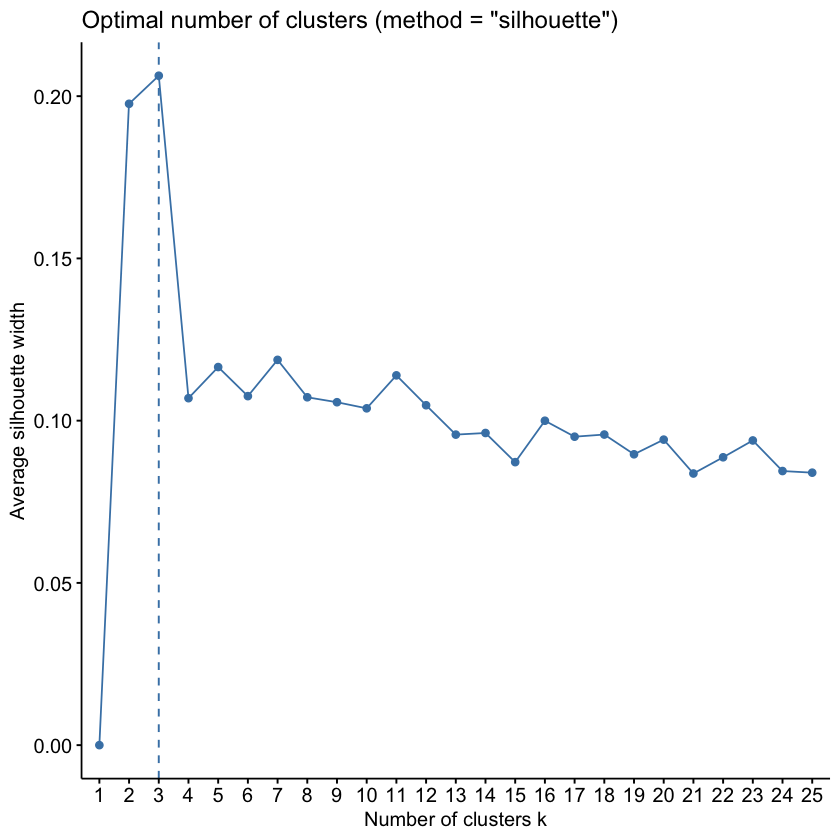

In [12]:
# inspect optimal clusters
fviz_nbclust(
  df,
  kmeans, 
  k.max = 25,
  method = "wss",
  diss = get_dist(df, method = "spearman")
)

fviz_nbclust(
  df, 
  kmeans, 
  method = "silhouette", 
  k.max = 25, 
  nstart = 25)

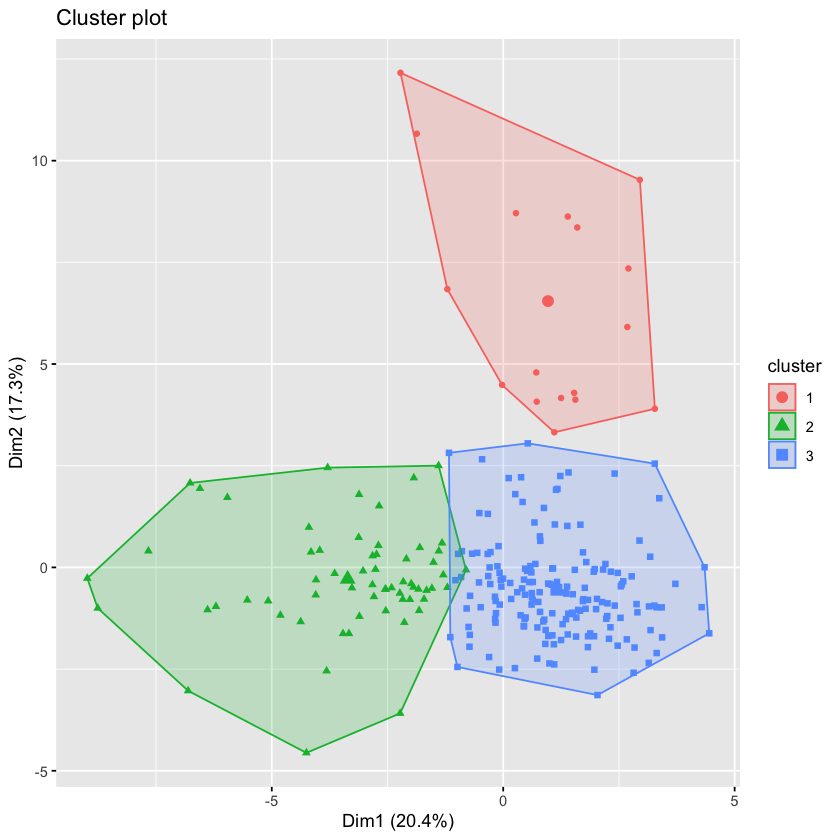

In [13]:
set.seed(100)
km <- kmeans(df, centers = 3, nstart = 25)
fviz_cluster(km, data = df, geom = "point", ellipse.type = "convex")

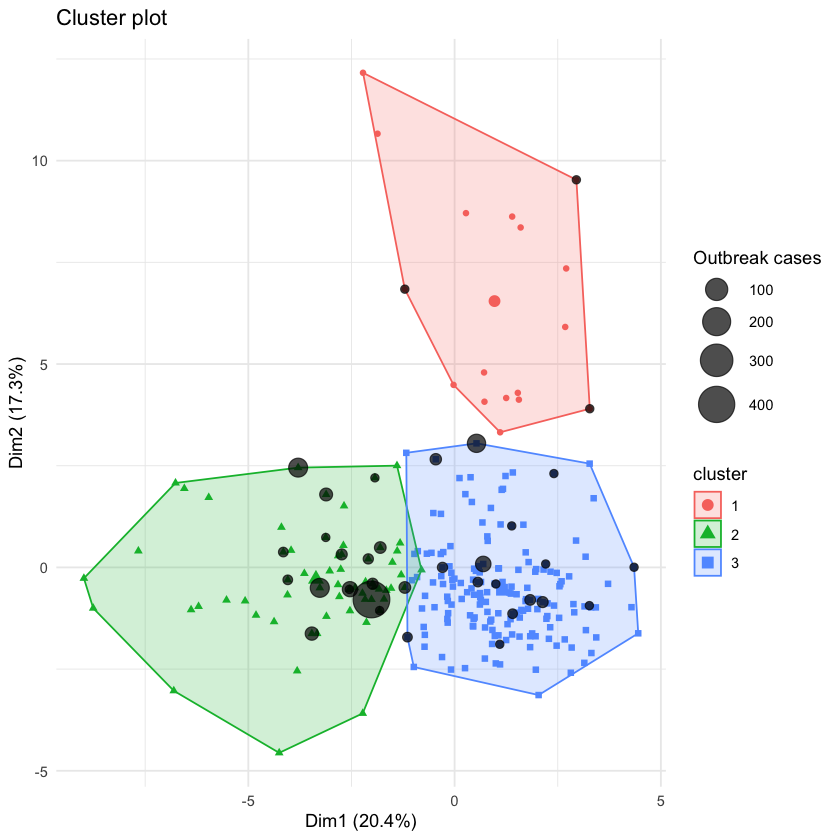

In [14]:
# get PCA coords
pca_coords <- as.data.frame(pca_out$x[, 1:2])
pca_coords$cluster <- factor(km$cluster)
pca_coords$outbreak <- df_raw$outbreak  # raw outbreak count

p <- fviz_cluster(km, data = df, geom = "point", ellipse.type = "convex") +
  theme_minimal()

# extract the PCA coords fviz already computed
plot_data <- p$data

# add outbreak from df_raw (make sure row order matches)
plot_data$outbreak <- df_raw$outbreak

# rebuild with sized points on top
p + 
  geom_point(data = plot_data %>% filter(outbreak > 0),
             aes(x = x, y = y, size = outbreak),
             color = "black", alpha = 0.7) +
  scale_size_continuous(range = c(2, 10), name = "Outbreak cases")

In [ ]:
# Analyzing results
# see centroid
centroids <- km$centers
print(centroids)
# see what loads heavily on PC1
pca_out <- prcomp(df)
names(pca_out)
sort(pca_out$rotation[, 1], decreasing = TRUE) %>% head(10)
sort(pca_out$rotation[, 1], decreasing = FALSE) %>% head(10)

          cve population pct_hispanic   pct_black  pct_white pct_poverty
1  0.05574497  2.5223173   -0.2154760  1.13288526 -0.6994891  -0.6287302
2 -0.59852131 -0.1547206    1.4070569 -0.48332686 -1.0824222   0.7678388
3  0.21623046 -0.1948941   -0.4998911  0.06582672  0.4710819  -0.2216790
  pct_uninsured pct_college pct_foreign_born    EP_UNEMP   EP_HBURD  EP_NOHSDP
1    -0.6546074  2.11169207       1.10932083  0.06296333  0.9226619 -0.8383684
2     0.9794615 -0.67854930       0.03842659  0.11664022  0.1081629  1.2123863
3    -0.2975162  0.04029318      -0.12517253 -0.04952183 -0.1323501 -0.3654593
    EP_AGE65   EP_AGE17  EP_DISABL   EP_SNGPNT    EP_LIMENG   EP_MUNIT
1 -1.1014057  0.2665331 -1.1812799  0.05122253 -0.006079104  2.5487011
2 -0.6689238  0.8473003 -0.3250307  0.69490194  1.010417159 -0.0897760
3  0.3580359 -0.3406528  0.2385805 -0.26264474 -0.373840802 -0.2216002
    EP_MOBILE    EP_CROWD   EP_NOVEH   EP_GROUPQ    EP_NOINT   EP_ASIAN
1 -1.29070996 -0.08719594 -0.2732616

[1] "sdev"     "rotation" "center"   "scale"    "x"

pct_white          cve     EP_AGE65  pct_college   EP_TWOMORE    EP_DISABL 
  0.33481873   0.21088536   0.20045796   0.19570852   0.16563618   0.05428499 
    EP_ASIAN    pct_black EP_OTHERRACE      EP_NHPI 
  0.03485572   0.03228008   0.03203957   0.01849488

pct_hispanic     EP_NOHSDP     EP_LIMENG pct_uninsured   pct_poverty 
   -0.3603811    -0.3380666    -0.3043091    -0.2692743    -0.2656737 
    EP_SNGPNT      EP_CROWD      EP_AGE17      EP_NOVEH      EP_NOINT 
   -0.2422412    -0.2348407    -0.2077236    -0.1987022    -0.1791407

In [2]:
# attach cluster assignments
df$cluster <- km$cluster
df$county <- County
df
# look at means of original variables by cluster
sum <- df %>%
  group_by(cluster) %>%
  summarise(across(where(is.numeric), mean))

cluster_label <- df %>% select(c(cluster, county))
write.csv(cluster_label, "data/cluster_labels.csv", row.names = FALSE)
write.csv(sum, "data/cluster_means.csv", row.names = FALSE)

ERROR: Error in eval(expr, envir, enclos): Objekt 'km' nicht gefunden


In [6]:
df <- read_csv("data/cluster_means.csv")
df <-  as.data.frame(t(df))
df_sorted <- df[order(abs(df$V3)), , drop = FALSE]
df_sorted

Rows: 3 Columns: 30
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl (30): cluster, cve, population, pct_hispanic, pct_black, pct_white, pct_...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


,V1,V2,V3
,<dbl>,<dbl>,<dbl>
EP_GROUPQ,-0.409510624,0.05249708,0.02149626
EP_AIAN,-0.233972942,0.14490347,-0.03030223
pct_college,2.111692066,-0.67854930,0.04029318
EP_NHPI,0.142939970,-0.15079078,0.04158729
EP_UNEMP,0.062963332,0.11664022,-0.04952183
EP_NOINT,-1.388885448,0.53554373,-0.05957766
EP_OTHERRACE,0.765677597,-0.04040024,-0.06159591
pct_black,1.132885260,-0.48332686,0.06582672
EP_MOBILE,-1.290709956,0.05583364,0.10837971
